# Algèbre linéaire et Python

Nous présentons, dans ce carnet, l'utilisation de Python et de l'extension Sympy pour la manipulation de matrices et de vecteurs.   

Plus particulièrement, ce carnet peut se diviser en différentes parties qui sont:

1) L'algèbre matricielle; 
2) La résolution de systèmes d'équations linéaires; 
3) L'algèbre et la géométrie vectorielle.

Le traitement des nombres complexes sera présenté dans un carnet distincts.

## <font color='red'> Utilisateurs de Google Colab: Installation requise de sympy plotting backends

Enlevez le # au début de l'entrée suivante et chargez la commande.

In [ ]:
#!pip install sympy_plot_backends[all]

## <font color='blue'> Librairies requises (à charger et à maîtriser)


L'utilisation de ce fichier repose sur la connaissance et l'usage des extensions SymPy, NumPy et des bibliothèques graphiques MatPlotLib et Plotly, entre autres.   De plus, nous assumerons qu'un laboratoire d'introduction portant sur les principales manipulations algébriques et les commandes graphiques de base a préalablement été réalisé.

Consultez les documents associés à ceux-ci, au besoin.

In [ ]:
# Nous chargeons toute l'extension sympy

from sympy import *

import numpy as np

## Algèbre matricielle 

Une référence qui comporte la majeure partie des commandes présentées ainsi que d'autres: https://docs.sympy.org/latest/modules/matrices/matrices.html

Définissons une matrice A carrée d'ordre 3 quelconque pour illustrer des commandes de base.

In [ ]:
A=Matrix(3,3,[1,2,3,4,5,6,7,8,1])  # Syntaxe similaire à Maple
A

### <font color='orange'> Dimensions, éléments, lignes, colonnes, etc.

Le nombre de lignes, de colonnes ou les dimensions d'une matrice peuvent être déterminées par des commandes existentes dans Sympy.

In [ ]:
shape(A)  # les dimensions de A (nombre de lignes, nombre de colonnes)

In [ ]:
len(A) # le nombre d'éléments de A

In [ ]:
A.rows  # Le nombre de lignes 

In [ ]:
A.cols # le nombre de colonnes

In [ ]:
A[:] # Les éléments de A lignes par lignes

In [ ]:
A.row(0)  # accès à la première ligne de A

In [ ]:
A.row(2) # accès à la troisième ligne de A

In [ ]:
A.col(1) # accès à la deuxième colonne de A

Nous pouvons aussi supprimer ou insérer des lignes ou des colonnes par les commandes row_del (col_del) et row_insert (col_insert)

In [ ]:
B  = A
B.row_del(0)   # row_del écrase la matrice d'origine
B

#### <font color='green'> Augmenter une matrice

Dans mes premiers tests en Python, je n'ai pas trouvé de commande qui permet d'augmenter des matrices.  Pour le faire, j'ai alors créé une commande qui le fait.  

Cette commande existe pourtant et voici son illustration.

In [ ]:
A=Matrix(3,3,[1,2,3,4,5,6,7,8,1])  
C = Matrix(3,3,[-1, 0, 2, 2,-2, 9, 1, 4,0])
A,C

In [ ]:
A.row_join(C)   # Augmente la matrice A par C à droite

In [ ]:
A.col_join(C) # Moins usuel au collégial, augmente A par C en bas.

### <font color='orange'> Opérations sur les matrices

La plupart des opérations matricielles courantes sont incluses dans Sympy.  En voici quelques unes bien que certaines ne sont pas toutes couvertes au collégial, hormis dans le cours d'Algèbre linéaire en S.I.M.

In [ ]:
transpose(A)   # La transposée

In [ ]:
det(A)    # le déterminant

In [ ]:
A.adjugate()   # retourne la matrice adjointe de A qui est la transposée de la matrice des cofacteurs de A

In [ ]:
A.cofactor_matrix()  # qui est la matrice des cofacteurs

In [ ]:
A.rank()  # Le calcul du rang de A

In [ ]:
A.trace()  # la somme des éléments sur la diagonale.

In [ ]:
A**2  # Une puissance

In [ ]:
# Le noyau d'une matrice ... l'espace vectoriel des vecteurs X satisfaisant AX = O
A.nullspace()   #ici, le noyau est vide ce qui est normal car la matrice est inversible.

In [ ]:
iA=A**(-1)  # l'inverse
iA

In [ ]:
A.inv()  # Autre manière

In [ ]:
A*iA  # Vérification

In [ ]:
B=Matrix(3,3,[4,2,0, -2,1,2, 2,3,2])  # B est une matrice singulière
C=Matrix(3,1,[1,2,3])


In [ ]:
det(B)  # Justifie que B est singulière 

In [ ]:
B.rank() # Justifie aussi que B est singulière car son rang est inférieur à son ordre (B est carrée)

In [ ]:
kerB = B.nullspace()  # Justifie d'une autre manière que B est singulière 

len(kerB)

In [ ]:
kerB[0]   # est un vecteur qui engendre le noyau qui est de dimension 1 par la ligne qui précède.

In [ ]:
2*A-3*B  # Une combinaison linéaire

In [ ]:
A*C  # Un produit

In [ ]:
# C*A # Ne devrait pas fonctionner... Enlevez le # au début de la ligne

In [ ]:
# Matrices particulières

I3=eye(3)  # La matrice identité d'ordre 3
I3


In [ ]:
N35=zeros(3,5) # La matrice nulle 3x5
N35

In [ ]:
D33 = diag(1,2,3)  # une matrice diagonale 3x3
D33

In [ ]:
Matrix(3,4, lambda i,j: 2**(i+j+2))   # Une matrice par assignation.  Ici, on adapte les indices

Les décompositions de matrices et le procédé de Gram-Schmidt est aussi possible.  Illustrons avec A.

https://docs.sympy.org/latest/modules/matrices/matrices.html

In [ ]:
L,U,P = A.LUdecomposition()
L

In [ ]:
U

In [ ]:
P  

In [ ]:
Q, R = A.QRdecomposition()
Q

In [ ]:
R

In [ ]:
# Orthogonalisation de Gram-Schmidt

L = [Matrix([2,3,5]), Matrix([3,6,2]), Matrix([8,3,6])]

GS=GramSchmidt(L) # on obtient de ceci une base orthogonale
BlockMatrix([GS[0], GS[1],GS[2]])

In [ ]:
GS=GramSchmidt(L, True) # on obtient de ceci une base orthonormée
BlockMatrix([GS[0], GS[1],GS[2]])

##  Algèbre et Géométrie vectorielle 

In [ ]:
# Un vecteur est une matrice-colonne.  Ainsi, pour définir un vecteur, on appelle la commande Matrix.   

# Illustrons des exemples pour les opérations usuelles
v=Matrix([1, -1, 0])

u=Matrix([1,1,1])


In [ ]:
# Produit scalaire
u.dot(v)

In [ ]:
# Combinaison linéaires
2*u+3*v

In [ ]:
# Produit vectoriel  uxv
u.cross(v)

In [ ]:
v.cross(u)  # vxu

In [ ]:
u.norm()

In [ ]:
# Angle entre deux vecteurs (Comme la plupart des logiciels, nous appliquons la formule)

acos(u.dot(v)/(u.norm()*v.norm()))    # on remarque l'écriture de arccos dans sympy

In [ ]:
# Projection orthogonale v sur u

# Nous pouvons créer une commande qui le fait ou appliquer la formule

def Proj(v,u):
    return (v.dot(u)/(u.norm())**2)*u

In [ ]:
Proj(v,u)  # ce qui fait du sens ici car u et v sont perpendiculaires

#### <font color='orange'> Les opérations sur les vecteurs sous forme matricielle

Pour certaines applications, il est intéressant de traiter les opérations sur les vecteurs comme le résultat d'opérations matricielles.   Voici quelques illustrations.

In [ ]:
# Soient les trois vecteurs suivants qui serviront dans les sous-sections suivantes:

u = Matrix([1,2,3])
v = Matrix([1,1,0])
w = Matrix([0,2,-1])

#### <font color='green'> Matrice de représentation d'une base

Illustrons en 3d.  Trois vecteurs, u, v et w, forment une base du 3d si la matrice engendrée par ces 3 vecteurs est inversible.  Cette matrice possède également d'autres propriétés utilisées dans les changements de bases.

In [ ]:
def Muvw(u,v,w):
    return (u.row_join(v.row_join(w)))

In [ ]:
M = Muvw(u,v,w)
M

In [ ]:
M.det()  # Le déterminant de la matrice de représentation est non nul. Ainsi, {u,v,w} forme une base du 3d.

#### <font color='green'> Norme euclidienne

In [ ]:
u.norm() # par la commande norm

In [ ]:
sqrt((u*transpose(u)).trace())  # par un produit matriciel et la trace d'une matrice.

#### <font color='green'> Produit scalaire

In [ ]:
# c'est plus ou moins pertinent mais néanmoins matriciel.

u.dot(v) # par la commande dot

In [ ]:
transpose(u)*v # par un produit matriciel.  Ici, le résultat est une matrice 1x1.

In [ ]:
(transpose(u)*v)[0]  # si on tient à avoir le "nombre".

#### <font color='green'> Matrice de la projection orthogonale sur u

In [ ]:
def Proj_u(u):
    k = (u*transpose(u))
    return k/k.trace()

In [ ]:
P = Proj_u(u)

P

In [ ]:
# Vérifions en calculant la projection de v sur u

In [ ]:
Proj(v,u)  # par la commande établie provenant de la définition

In [ ]:
P*v   # par la matrice définie.  La projection s'obtient alors par un produit matriciel.

De la matrice P qui précède, nous pouvons déduire deux autres matrices.   La première interviendrait dans la construction de base et la seconde dans une formulation matricielle du produit vectoriel.

In [ ]:
def O_u(u):
    n = shape(u)[0]
    return eye(n)-Proj_u(u)

In [ ]:
O=O_u(u)
O

In [ ]:
def C_u(u):   #  Valide pour le 3d seulement
    n = shape(u)[0]
    return Matrix(n,n,[0, -u[2], u[1], u[2],0, -u[0], -u[1], u[0],0])
    

In [ ]:
C = C_u(u)
C

#### <font color='green'> Produit vectoriel u x ...

La matrice C_u construite à la section précédente permet de récupérer le produit vectoriel comme un produit matriciel.

Illustrons

In [ ]:
u.cross(v) # par la commande cross

In [ ]:
C_u(u)*v # par la matrice C_u définie

#### <font color='green'> Construction de base orthogonale

Voici une manière "rapide" de constuire une base orthogonale du 3d impliquant les vecteurs u et v et exploitant les matrices associées, par exemple, à u.

In [ ]:
u1 = u

v1 = O_u(u)*v

w1 = C_u(u)*v

In [ ]:
M = Muvw(u1,v1,w1)
M

##   Bases et repères 

Toute construction vectorielle repose sur les notions de base et vecteurs.   Pour les besoins des sections qui suivront, nous avons besoin d'éléments et de constructions s'y rattachant. 

In [ ]:
# Normalisation d'un vecteur
def Normalize(u):
    N=u.norm()
    return u/N

In [ ]:
u=Matrix(2,1,[2,2])

Normalize(u)

### <font color='orange'> Écriture d'un vecteur selon une base

In [ ]:
# Reprenons les vecteurs u, v et w 

u = Matrix([1,2,3])
v = Matrix([1,1,0])
w = Matrix([0,2,-1])


In [ ]:
# Ils forment bien une base

M = Muvw(u,v,w)

M.det()

In [ ]:
# Soit le vecteur 

t = Matrix([-4,2,1])
t

In [ ]:
# L'écriture de t dans la base {u,v,w} s'obtiendrait par 

M**(-1)*t

Nous pouvons faire beaucoup plus.  Nous ne détaillerons pas tout dans ce carnet.

### <font color='orange'> Former une base à partir d'un seul vecteur

In [ ]:
# Construit une base orthonormée selon le vecteur u 
def BaseN(u):
    if len(u)==2:
        v=Normalize(u)
        w=Matrix(2,1,[-v[1], v[0]])
        return [v,w]
    else:
        v=Normalize( Matrix(3,1,[-u[1],u[0], 0]))
        w=Normalize( u.cross(v))
        if v.norm()!=0:
            return [ Normalize(u), v,w]
        else:
            if u[2]>0:
                return [Normalize(u),Matrix(3,1,[1,0,0]),Matrix(3,1,[0,1, 0])]
            else:
                return [Normalize(u),Matrix(3,1,[0,1,0]),Matrix(3,1,[1,0, 0])]
        

In [ ]:
u=Matrix(3,1,[1,1,0])

B = BaseN(u)

Muvw(B[0] , B[1], B[2])

##  Représentation de vecteurs 

J'ai consacré beaucoup de temps à chercher comment insérer des vecteurs représentés par une flèche qui pourraient s'afficher, principalement en 3d, avec comme backend PB.  J'ai finalement retenu l'idée de créer des vecteurs en 3d comme la combinaison de deux surfaces paramétrées (un cylindre et un cône).

Les cellules qui suivent comportent deux commandes personnalisées nommées Arrow2d et Arrow3d dont la syntaxe est:

Arrow2d(u, couleur, A)   où u est un vecteur (matrice 2x1 ou matrice 3x1 pour Arrow3d), la couleur voulue et A est un paramètre facultatif qui représente l'origine du vecteur.  Par défaut, l'origine est [0,0,0]. 

Une référence utilisée mais qui a, somme tout, été peu retenue.

https://sympy-plot-backends.readthedocs.io/en/v3.1.1/modules/graphics/vectors.html#spb.graphics.vectors.arrow_2d

<font color='red'> Note: L'exécution de ces commandes peut éventuellement être lourde.  Il serait avantageux dans d'autres versions de trouver des commandes qui le font (arrow, quiver).

In [ ]:
from spb import *

In [ ]:
# Les commandes utilisent les commandes personnalisées suivantes qui sont ici rappelées.

# Normalisation d'un vecteur
def Normalize(u):
    N=u.norm()
    return u/N
    
# Construit une base orthonormée selon le vecteur u 
def BaseN(u):
    if len(u)==2:
        v=Normalize(u)
        w=Matrix(2,1,[-v[1], v[0]])
        return [v,w]
    else:
        v=Normalize( Matrix(3,1,[-u[1],u[0], 0]))
        w=Normalize( u.cross(v))
        if v.norm()!=0:
            return [ Normalize(u), v,w]
        else:
            if u[2]>0:
                return [Normalize(u),Matrix(3,1,[1,0,0]),Matrix(3,1,[0,1, 0])]
            else:
                return [Normalize(u),Matrix(3,1,[0,1,0]),Matrix(3,1,[1,0, 0])]


In [ ]:
def Arrow2d(u,couleur,A=[0,0], Axis_center=[0,0], Aspect="equal" ):   # forme très simple de flèche

    theta, r, t = symbols('theta, r t')

    B=BaseN(u)
    vA=Matrix(2,1,A)
    
    L=(u).norm()
    
    Head_length = (0.05)*L
    Tige_length = L-Head_length
    Tige_width = (0.025)*L
    Head_angle=pi/6

    Pt1 = vA+Tige_width/2*B[1]
    Pt2 = Pt1+Tige_length*B[0]
    Pt3 = Pt2+Tige_width/2*B[1]
    Pt4 = vA+u
    Pt5 = Pt4-Head_length*B[0]-Tige_width*B[1]
    Pt6 = Pt5+ Tige_width/2*B[1]
    Pt7 = Pt6-Tige_length*B[0]

    Lx = [ Pt1[0], Pt2[0],Pt3[0],Pt4[0],Pt5[0],Pt6[0], Pt7[0],Pt1[0] ]
    Ly = [ Pt1[1], Pt2[1],Pt3[1],Pt4[1],Pt5[1],Pt6[1], Pt7[1],Pt1[1] ]

    s = plot_list( Lx, Ly, rendering_kw ={"color":couleur},show=False, axis_center=Axis_center,aspect=Aspect)

    return s

In [ ]:
( Arrow2d(Matrix(2,1,[1,0]),'blue')+ 
         Arrow2d(Matrix(2,1,[0,1]),'red')+ 
         Arrow2d(Matrix(2,1,[1,1]),'black')+ 
         Arrow2d(Matrix(2,1,[-1,-2]),'green', [0,1])
         ).show()


In [ ]:
# Commande Arrow3d 
def Arrow3d(u,couleur,A=[0,0,0], be=PB, Aspect="equal"):    
    
    # u le vecteur donné par une matrice 3x1 
    # sa couleur, 
    # son origine qui est, par défaut, [0,0,0] 
    # le backend voulu qui est par défaut PB pour plotly     # BUG !!! la couleur ne marchera pas avec autre que Plotly

    theta, r, t = symbols('theta, r t')

    B=BaseN(u)
    vA=Matrix(3,1,A)
    
    L=(u).norm()
    
    Head_length = (0.05)*L
    Head_angle=pi/6
    
    xyz=(vA+u) + (-1)*(r*cos(theta)*sin(Head_angle)*B[1]+ r*sin(theta)*sin(Head_angle)*B[2]+ r*cos(Head_angle)*B[0])

    s1=plot3d_parametric_surface(xyz[0], xyz[1],xyz[2], (theta, 0, 2 * pi), (r, 0, Head_length),
                                 rendering_kw={"colorscale":[[0, couleur], [1,couleur]],"showscale":False},
                                 legend=False,aspect=Aspect,show=False,backend=be)

    r_tige =  0.375*Head_length*tan(Head_angle)

    xyz=vA+t*B[0]+r_tige*(cos(theta)*B[1]+sin(theta)*B[2])
    

    s2=plot3d_parametric_surface(xyz[0], xyz[1],xyz[2], (theta, 0, 2 * pi), (t, 0,(L-Head_length*tan(Head_angle))),
                                  rendering_kw={"colorscale":[[0, couleur], [1,couleur]],"showscale":False},
                                 legend=False,aspect=Aspect,show=False,backend=be)

    return s1+s2

In [ ]:
vI=Matrix(3,1,[1,0,0])
vJ=Matrix(3,1,[0,1,0])
vK=Matrix(3,1,[0,0,1])

u=Matrix(3,1,[1,1,1])

(Arrow3d(vI, 'blue')+ Arrow3d(vJ,'green') + Arrow3d(vK, 'red')+
         Arrow3d(u, 'black')+Arrow3d(u, 'black',[0.5,0.5,0])).show()

## Droites et plans dans l'espace

Ce qui précède comporte ce dont nous avons besoin pour tracer des droites et des plans.

Nous illustrerons, dans ce carnet, en 3d seulement.

In [ ]:
# Droite vectorielle

# La droite passant par A parallèle à v donnés

A=[0, 2,3]

v=Matrix(3,1,[1,1,-1])

t = symbols('t')

eqD = Matrix(3,1,A)+ t*v

eqD


In [ ]:
gD=plot3d_parametric_line(eqD[0], eqD[1], eqD[2], (t,-1,3), use_cm=False,backend=PB, legend= False,show=False)

gPt = plot3d_list(A[0], A[1],A[2], scatter=True, backend=PB,show=False)

(gD+gPt+Arrow3d(v,'green', A)).show()

La représentation d'un plan peut se faire via son équation vectorielle ou son équation normale.

L'équation vectorielle facilite la représentation et le contrôle des paramètres et constitue par ce fait une manière plus fonctionnelle.

L'équation normale (aussi appelée algébrique) peut se faire avec un graphique de fonctions implicites ou via la commande plane décrite plus bas.   

Illustrons principalement dans ce carnet la représentation d'un plan par son équation vectorielle.

In [ ]:
# Forme vectorielle d'un plan

# Illustration du plan passant par A et ayant pour vecteurs directeurs les vecteurs u et v donnés.


A=[0, 2,3]

u = Matrix([-1,1,0])
v = Matrix([1,1,-1])

t,k = symbols('t k')

eqPlan =  Matrix(3,1,A)+ t*u + k*v
eqPlan

In [ ]:
gPlan=plot3d_parametric_surface(eqPlan[0], eqPlan[1], eqPlan[2], (t,-1,2),(k,-1,2), use_cm=False,
                        rendering_kw={"colorscale":[[0, 'cyan'], [1,'cyan']],"showscale":False, "opacity":0.5}, 
                        wireframe=True, wf_n1=4, wf_n2 = 4,
                        show=False, legend=False, backend=PB)

gPt = plot3d_list(A[0], A[1],A[2], scatter=True, backend=PB,show=False)

(gPlan+gPt+Arrow3d(u,'green', A)+Arrow3d(v,'red', A)+Arrow3d(v.cross(u), 'blue', A)).show()

In [ ]:
# Illustration avec l'équation normale
x,y,z = symbols('x,y,z')
n = v.cross(u)
X = Matrix([x,y,z])

eqNplan= n.dot(X)-n.dot(A)
eqNplan

In [ ]:
A


In [ ]:
geqNplan=plot3d_implicit(eqNplan, (x,-2,3),(y,0,5),(z, 1, 7), show=False, legend = False, backend=PB)

gn = Arrow3d(n, "green", A)
(geqNplan+gPt+gn).show()

In [ ]:
# Illustration de la commande plane

# Notez que nous utilisons une autre type d'interface graphique comprise dans sympy.plotting.backends.   
# Je n'aime pas trop ajouter quelque chose de plus qui peut être éviter.

x,y,z = symbols("x y z")
ranges = [(x, -5, 5), (y, -5, 5), (z, -5, 5)]

graphics(
    plane(Plane((0, 0, 0), (1, 1, 1)), *ranges, n=150),
    backend=PB 
)

## Résolution de S.E.L.

### <font color='orange'> Échelonnages selon Gauss et Gauss-Jordan

In [ ]:
#Résolution de la matrice augmentée par la méthode de Gauss-Jordan

C=Matrix([[1,2,3,1], [4,5,6,2], [7,8,1,3]])  # Montre une autre manière de définir une matrice
C

La commande echelon_form retourne une matrice sur laquelle fut appliqué l'algorithme de Gauss.  Cette matrice n'est pas unique.

In [ ]:
C.echelon_form()

La commande rref pour ReducedRowEchelonForm existe dans sympy et effectue l'échelonnage selon Gauss-Jordan.

In [ ]:
C.rref() #  Sans ajout, elle donne la matrice échelon réduite et les colonnes comportant des pivots.

In [ ]:
C.rref()[0]

#### <font color='green'> Différentes illustrations de rref

In [ ]:
C=Matrix(3,3,[1,2,3,0,4,5,0,0,0])
C

In [ ]:
C.rref()  # fournit la matrice de Gauss-Jordan 
           #et informe que les colonnes contenant des pivots aussi appelées les variables liées sont la 1ère et la 2e

In [ ]:
C=Matrix(3,3,[1,2,3,0,0,5,0,0,0]) 
C

In [ ]:
C.rref() # fournit la matrice de Gauss-Jordan 
           #et informe que les colonnes contenant des pivots aussi appelées les variables liées sont la 1ère et la 2e

### <font color='orange'> Résolution de S.E.L.

#### <font color='green'> Par la commande solve_linear_system

In [ ]:
A=Matrix(3,3,[1, 2, -3, 2,4,0,-1,3,2])
B=Matrix([5, -8,13])

C = A.row_join(B)
C

In [ ]:
# Recherche de la solution  : 1ère méthode 

# Utiliser la commande solve_linear_system qui retourne un "dictionnaire"

x,y,z=symbols('x,y,z')
            
SOL=solve_linear_system(C, x, y,z)
SOL

In [ ]:
# On montre ici comment récupérer les éléments du "dictionnaire"

ES=[SOL.get(x), SOL.get(y),SOL.get(z)]
ES

##### <font color='purple'> Autres illustrations avec solve_linear_system

Cette méthode reconnait les cas où il n'y a pas de solution ou s'il y en a une infinité.

Illustrons avec les matrices suivantes:

In [ ]:
C1=Matrix([[1,2,3,1], [0,5,6,2], [0,0,0,3]])  # Ce système n'admet pas de solution
C1

In [ ]:
SOL=solve_linear_system(C1, x, y,z)
SOL

Rien n'est retourné.  Ceci signifie qu'il n'y a pas de solution.

In [ ]:
C2=Matrix([[1,2,3,1], [0,5,6,2], [0,0,0,0]])  # Ce système n'admet pas de solution
C2

In [ ]:
SOL=solve_linear_system(C2, x, y,z)
SOL

La variable $z$ est libre.  Nous verrons comment la traiter et donner une réponse plus conventionnelle comme il est généralement enseigné.

#### <font color='green'> Par substitution arrière d'une matrice échelonnée : VERSION "FAIBLE"

In [ ]:
# Recherche de la solution  : 2e méthode 

# Utiliser une sustitution-arrière d'après la matrice augmentée échelon ou échelon-réduite

# Comme je ne trouve pas de commande qui le fait... j'en crée une!   
# Cette version est naïve car on assume ici qu'il y a une solution unique.
# Je présenterai ultérieurement une manière rigoureuse prenant en charge les systèmes comportant des solutions paramétrées.

def Weak_Backsub(C):# On assume donc que C est la matrice échelonnée
    m=len(C[:,0])   # le nombre de lignes de C
    n=len(C[0,:])   # le nombre de colonnes de C

    B=C[:,n-1]      # Les éléments de la dernière colonne de C
    
    L=zeros(m,1)
    for i in range(m-1, -1, -1):
        L[i, 0]=B[i]
        for j in range(i+1, m):
            L[i]-= C[i,j]*L[j]
        L[i, 0] /=C[i,i]
    return L

In [ ]:
Weak_Backsub(C.echelon_form())  # C doit être échelonnée...

In [ ]:
ES

#### <font color='green'> Par substitution arrière d'une matrice échelonnée : VERSION "COMPLÈTE"

Une version complète et comportant du symbolique doit pouvoir traiter et s'appliquer à toute équation matricielle de la forme $AX=B$.

Ainsi, nous devons prendre en compte les cas de solution unique, d'aucune solution et d'infinité de solutions qui produiront une solution comportant un ou plusieurs paramètres.

In [ ]:
def Backsub(C):
    CC = C.echelon_form()   # on s'assure de travailler avec une matrice augmentée échelon
    
    m = CC.rows
    n = CC.cols

    Var = [j for j in range(0,n-1)] # Les indices des variables
    LinkVar = CC.rref()[1]         # Les variables liées s'obtiennent de rref
    FreeVar = []    # Nous créons la liste des variables libres
    for j in Var:
        if j not in LinkVar:
            FreeVar.append(j)

    # On crée la matrice des coefficients
    A=zeros(m,n-1)
    for i in range(0,m):
        for j in range(0,n-1):
            A[i,j]=CC[i,j]
            
    # Les éléments de la dernière colonne de C
    B = CC[:,n-1]
    
    # S'il n'y a pas de solution, on arrête après ce qui suit
    if A.rank() < CC.rank():
        return "Aucune solution"

    # S'il y a des solutions, nous déterminerons celles-ci d'après le noyau de A.
    
    # On calcul le noyau de A et la liste des paramètres indicés dont nous aurons besoin
    kerA = A.nullspace()
    
    t = IndexedBase('t')
    k = Idx('k', (1, len(kerA)+1))
    

    ###############################################################################
    # On crée d'abord la solution particulière

    # Pour cela,nous résolvons un système "carré" en posant les variables libres nulles
    AA = zeros(len(LinkVar), len(LinkVar))
    BB = zeros(len(LinkVar),1)
    for i in range(0, len(LinkVar)):
        for j in LinkVar:
            AA[i,LinkVar.index(j)] = CC[i,j]
            BB[i,0] = B[i,0]
    XX = Weak_Backsub(AA.row_join(BB))

    # On crée la solution particulière en insérant des 0 aux variables libres.
    Lxx = [ XX[i,0] for i in range(0, len(LinkVar))]
    for j in FreeVar:
        Lxx.insert(j,0)
    ES = Matrix(len(Lxx),1, Lxx)   # Ceci est la solution particulière
    ###################################################################################################
    
    # On forme la solution à retourner qui prend en compte le noyau s'il n'y a pas une solution unique.
    for i in range(0,len(kerA)):
        for k in range(0, n-1):
            ES[k,0] += t[i+1]*kerA[i][k]
    return ES
    


Illustration pour l'exemple de cette section

In [ ]:
Backsub(C)

##### <font color='purple'> Diverses illustrations de la commande personnalisée Backsub

In [ ]:
C1=Matrix([[1,2,3,1], [0,5,6,2], [0,0,0,3]])  # Ce système n'admet pas de solution
C1

In [ ]:
Backsub(C1)

In [ ]:
C2=Matrix([[1,2,3,1], [0,1,1,2], [0,0,2,3]])  # Ce système admet une solution unique
C2

In [ ]:
Backsub(C2)

In [ ]:
A = Matrix([[1,0,1], [0,1,1], [0,0,0]])
B = Matrix([1,2,0])

C3=A.row_join(B)  # Ce système admet une infinité de solutions
C3

In [ ]:
Backsub(C3)

In [ ]:
A = Matrix([[1,0,1], [0,0,1], [0,0,0]])
B = Matrix([1,2,0])

C4=A.row_join(B)  # Ce système admet une infinité de solutions dont la seconde variable est libre.
C4

In [ ]:
Backsub(C4)

In [ ]:
A = Matrix([[1,1,1], [0,0,0], [0,0,0]])
B = Matrix([1,0,0])

C5=A.row_join(B)  # Ce système admet une infinité de solutions comportant deux paramètres.
C5

In [ ]:
Backsub(C5)

##### <font color='purple'> Test aléatoire de la commande Backsub

Pour tester la validité d'une commande matricielle personnalisée, comme ici la commande Backsub, je propose habituellement de générer aléatoirement une matrice de relativement grand format pour ensuite valider la concordance en utilisant un autre logiciel.   

J'utiliserai Maple pour valider.  

La marche à suivre est adaptable et peut se faire dans un sens comme dans l'autre.  Vous êtes invités à consulter le carnet sur la lecture et l'écriture de fichiers txt. 

Voici ce qui sera fait:

1) On crée une matrice aléatoire quelconque qui représenterait la matrice augmentée associée à un S.E.L.;
2) On résoud ce système avec la commande Backsub;
3) On écrit la matrice aléatoire de départ dans un fichier txt;
4) On lit ce fichier txt dans un autre logiciel (ici, Maple) et on utilise les fonctionnalités de ce logiciel pour s'assurer la concordance des résultats.

Ce procédé peut se faire dans l'autre sens qui consiste à créer la matrice et le fichier txt dans le logiciel tiers et l'importer en Python.

Les sous-sections qui suivent comportent certains éléments non présentés dans ce carnet.

###### <font color='blue'> CRÉATION DE MATRICE ALÉATOIRE

La création de matrices aléatoires se fait avec la commande randMatrix.   Nous pouvons ajouter à cette commande diverses options.

In [ ]:
randMatrix(3,4)  # une matrice aléatoire 3x4 dont les entrées sont des entiers entre 0 et 99

In [ ]:
randMatrix(6,6, symmetric=True)  # une matrice aléatoire symétrique

In [ ]:
randMatrix(5,7,-50,50)  # une matrice aléatoire dont les entrées sont des entiers entre -50 et 50

In [ ]:
(randMatrix(3,5,0,100)/100)  # une manière d'obtenir une matrice aléatoire d'éléments entre 0 et 1.

In [ ]:
randMatrix(5,7, percent=50)  # Une matrice aléatoire avec un pourcentage approximation d'éléments non nuls

# Ceci a de l'intérêt pour les tests

###### <font color='blue'> CRÉATION DE FICHIER txt

Générons une matrice aléatoire, $C$, représentant la matrice augmentée d'un système d'équations linéaires.  


In [ ]:
C = randMatrix(4,7, percent=50)
C

Résolution du système donné par la matrice $C$

In [ ]:
ES = Backsub(C)
ES

In [ ]:
# La forme numérique peut être prise en compte
ES.evalf()

Écriture de la matrice $C$ aléatoire dans un fichier txt.   Nous nommerons ce fichier Crand.txt.


In [ ]:
C

In [ ]:
C.row(1)

In [ ]:
Crow = []
for i in range(0,C.rows):
    Crow.append(C.row(i))

with open('Crand.txt', 'w') as testfile:   # On ouvre un fichier txt nommé Crand.txt en mode écriture
    for row in Crow:
        testfile.write(' '.join([str(a) for a in row]) + '\n')

Dans le dossier comportant ce carnet, un fichier txt a été créé.

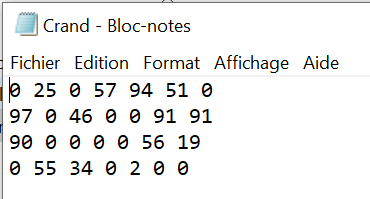

Vous pouvez utiliser le fichier Maple (si vous avez le logiciel) qui est déposé dans le dossier pour lire le fichier Crand.txt et tester la solution obtenue de Backsub.

<font color='blue'> Réponse en Python

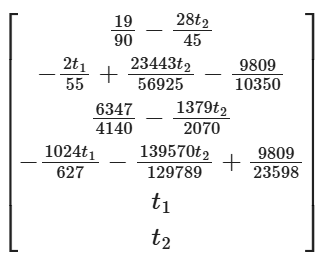

<font color='blue'> Réponse en Maple

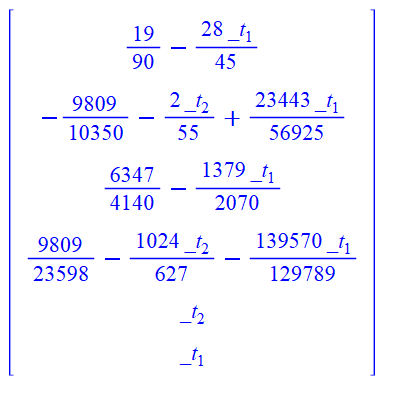

#### <font color='green'> Par la méthode de la matrice inverse

In [ ]:
# Illustration par la méthode de la matrice inverse

A=Matrix(3,3,[1, 2, -3, 2,4,0,-1,3,2])
B=Matrix([5, -8,13])

A.inv()*B

#### <font color='green'> Par les décompositions LU ou PLU

Nous traiterons, dans ce carnet, la résolution d'une équation matricielle du type $AX=B$ où $A$ est carrée et inversible pour illustrer la résolution d'un tel système à la manière LU.


In [ ]:
A=Matrix(3,3,[1, 2, -3, 2,4,0,-1,3,2])
B=Matrix([5, -8,13])

In [ ]:
L,U,Perm=A.LUdecomposition()

In [ ]:
L

In [ ]:
U

In [ ]:
Perm # Indique une permutation des lignes 2 et 3.   Donc, A admet une décomposition PLU

In [ ]:
# Recherche de la matrice de permutation P telle que PA = LU
P = eye(A.rows).permuteFwd(Perm)
P

In [ ]:
# Si A admet une décomposition PLU, c'est donc que PA = LU
P*A

In [ ]:
L*U

Pour résoudre $AX=B$ à la manière LU, nous résolvons 

i) $LY=P^{-1}B$ par des substitutions avant

ii) $UX = Y$ par des substitutions arrière

Nous devons donc disposer d'une méthode qui effectue les susbtitutions avant.

In [ ]:
# Substitution avant
def Forwardsub(C): # On assume donc que C est la matrice échelonnée
    m=C.rows  # le nombre de lignes de C
    n=C.cols   # le nombre de colonnes de C

    B=C[:,n-1]      # Les éléments de la dernière colonne de C
    
    L=zeros(m,1)
    for i in range(0,m):
        L[i,0]=B[i]
        for j in range(0, i):
            L[i, 0]-= C[i,j]*L[j]
        L[i, 0] /=C[i,i]
    return L

In [ ]:
Y=Forwardsub((L.row_join(P.inv()*B))) 
Y

In [ ]:
#X = Backsub(U.row_join(Y))

X = Weak_Backsub(U.row_join(Y))
X

### <font color='orange'> Traduction et résolution d'un système d'équations linéaires

In [ ]:
# Travaillons avec des équations

x,y,z = symbols('x,y,z')

eq1= Eq(x+2*y+3*z,1)     # Formalisme pour créer des équations 
eq2= Eq(4*x+5*y+6*z, 2)
eq3= Eq(7*x+8*y+z,3)

eqns=[eq1,eq2,eq3]       # la liste des équations

In [ ]:
# La commande suivante s'utilise comme celle de Maple.   Elle forme les matrices A et B associées au SEL

A, B = linear_eq_to_matrix(eqns, [x, y, z])

In [ ]:
A   #Matrice des coefficients

In [ ]:
B   # Matrice des constantes

In [ ]:
# Je n'avais pas trouvé comment faire des matrices augmentées... J'avais donc créé une commande qui le faisait.

# Nous pouvons la conserver ou utiliser row_join

def Augment(A,B):
    mA=len(A[:,0])   # le nombre de lignes de A
    nA=len(A[0,:])   # le nombre de colonnes de A

    mB=len(B[:,0])   # le nombre de lignes de B
    nB=len(B[0,:])   # le nombre de colonnes de B

    if mA != mB:
        return Err

    C=zeros(mA, nA+nB)

    for i in range(mA):
        for j in range(nA):
            C[i,j]=A[i,j]
        for j in range(nB):
            C[i, j+nA]=B[i,j]
    return C

    

In [ ]:
C=Augment(A,B)
C

In [ ]:
A.row_join(B) # La commande personnalisée Augment fait donc comme row_join

In [ ]:
# La résolution qui suit est la même que celle précédemment présentée

E=C.echelon_form()
E

In [ ]:
Weak_Backsub(E)